# Degrau de Potencial sob Controle Difusional

## Bibliotecas Necessárias:

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from ipywidgets import Text, Button, HBox, VBox, Output
from IPython.display import display, clear_output

## Definindo o Modelo:

In [2]:
model = pybamm.BaseModel()

c = pybamm.Variable("Concentração", domain="electrolyte")

N    = -pybamm.grad(c)   # fluxo difusional de c
dcdt = -pybamm.div(N)    # lei de Fick (eq. 1.0)

model.rhs = {c: dcdt}

# condição inicial (eq. 1.1): concentração uniforme adimensionalizada
model.initial_conditions = {c: pybamm.Scalar(1)}

# condições de contorno — Dirichlet
# esquerda (x=0): superfície do eletrodo — condição de Cottrell (eq. 1.3)
# direita  (x=6): seio da solução        — difusão semi-infinita  (eq. 1.2)
model.boundary_conditions = {
    c: {
        "left":  (pybamm.Scalar(0), "Dirichlet"),
        "right": (pybamm.Scalar(1), "Dirichlet"),
    }
}

model.variables = {"Concentração": c, "Fluxo": N}

# ── geometria e malha ────────────────────────────────────────────────────────
x_var = pybamm.SpatialVariable("x", domain=["electrolyte"], coord_sys="cartesian")

geometry = {"electrolyte": {x_var: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(6)}}}

submesh_types = {"electrolyte": pybamm.Uniform1DSubMesh}
var_pts       = {x_var: 400}
mesh          = pybamm.Mesh(geometry, submesh_types, var_pts)

spatial_methods = {"electrolyte": pybamm.FiniteVolume()}
disc = pybamm.Discretisation(mesh, spatial_methods)
disc.process_model(model)

## Solução Numérica:

In [3]:
# O modelo do Cottrell não tem parâmetros livres: resolve-se uma única vez.
# O resultado fica disponível para o gráfico estático e o interativo.

solver = pybamm.ScipySolver()
t      = np.linspace(1e-5, 1, 1000)

solucao = solver.solve(model, t)

c_sol = solucao["Concentração"]   # interpolável em qualquer (x, t)
N_sol = solucao["Fluxo"]          # interpolável em qualquer (x, t)

## Funções Analíticas

In [4]:
def c_analitica(x, t):
    """Solução analítica de concentração: c(x,t) = erf(x / 2√t)"""
    return special.erf(x / (2 * np.sqrt(t)))

def i_analitica(t):
    """Corrente analítica adimensional: i(t) = −1/√(πt)
    Negativa por convenção catódica (redução).
    """
    return -1 / np.sqrt(np.pi * t)

## Gráfico Estático:

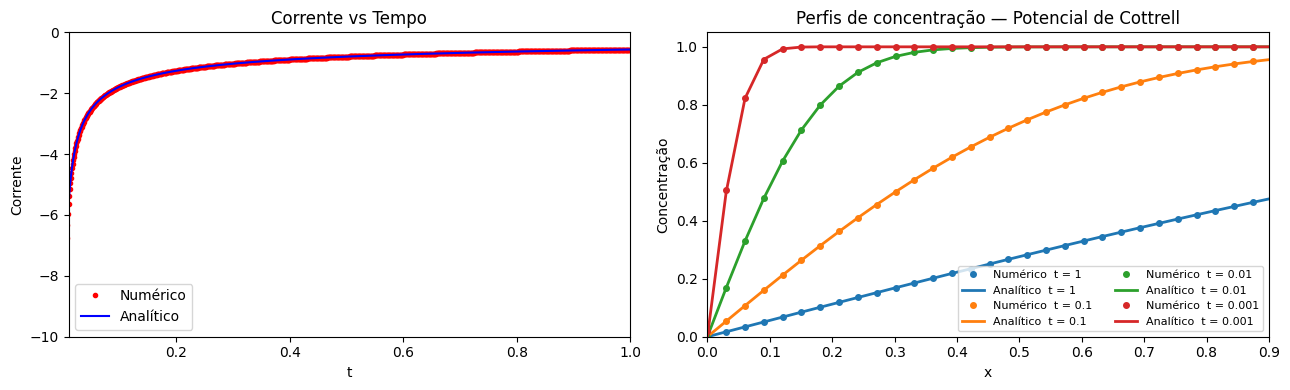

In [5]:
x_plot = np.linspace(0, 6, 200)
tempos = [1, 0.1, 0.01, 0.001]
cores  = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ti, cor in zip(tempos, cores):
    # numérico — pontos
    ax2.plot(
        x_plot,
        c_sol(t=ti, x=x_plot),
        ".",
        color=cor,
        markersize=8,
        label=f"Numérico  t = {ti}",
    )
    # analítico — linha sólida
    ax2.plot(
        x_plot,
        c_analitica(x_plot, ti),
        "-",
        color=cor,
        linewidth=2,
        label=f"Analítico  t = {ti}",
    )

ax2.set_xlabel("x")
ax2.set_ylabel("Concentração")
ax2.set_xlim([0, 0.9])
ax2.set_ylim([0, 1.05])
ax2.set_title("Perfis de concentração — Potencial de Cottrell")
ax2.legend(fontsize=8, ncol=2)

ax1.plot(solucao.t, N_sol(solucao.t, x=0), "r.", label="Numérico")
ax1.plot(solucao.t, i_analitica(solucao.t), "b-", label="Analítico")
ax1.set_xlabel("t")
ax1.set_ylabel("Corrente")
ax1.set_xlim([0.01, 1])
ax1.set_ylim([-10, 0])
ax1.legend()
ax1.set_title("Corrente vs Tempo")

plt.tight_layout()
plt.show()

## Gráfico Interativo:

In [6]:
x_plot = np.linspace(0, 6, 200)

saida = Output()

def plotar(tempo_1, tempo_2):
    with saida:
        clear_output(wait=True)

        try:
            t1 = float(tempo_1)
            t2 = float(tempo_2)
        except ValueError:
            print("Por favor, insira valores numéricos válidos.")
            return

        if not (1e-5 <= t1 <= 1) or not (1e-5 <= t2 <= 1):
            print("Os tempos devem estar entre 1×10⁻⁵ e 1.")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

        for ti, cor, rotulo in [
            (t1, "tab:blue", "1° Tempo"),
            (t2, "tab:red",  "2° Tempo"),
        ]:
            ax2.plot(
                x_plot,
                c_sol(t=ti, x=x_plot),
                ".",
                color=cor,
                markersize=10,
                label=f"Numérico  — {rotulo} (t = {ti})",
            )
            ax2.plot(
                x_plot,
                c_analitica(x_plot, ti),
                "-",
                color=cor,
                linewidth=2,
                label=f"Analítico — {rotulo} (t = {ti})",
            )

        ax2.set_xlabel("x")
        ax2.set_ylabel("Concentração")
        ax2.set_xlim([0, 1])
        ax2.set_ylim([0, 1.05])
        ax2.set_title("Perfis de concentração — Potencial de Cottrell")
        ax2.legend(fontsize=8)

        ax1.plot(solucao.t, N_sol(solucao.t, x=0), "r.", label="Numérico")
        ax1.plot(solucao.t, i_analitica(solucao.t), "b-", label="Analítico")
        ax1.set_xlabel("t")
        ax1.set_ylabel("Corrente")
        ax1.set_xlim([0.01, 1])
        ax1.set_ylim([-10, 0])
        ax1.legend()
        ax1.set_title("Corrente vs Tempo")

        plt.tight_layout()
        display(fig)
        plt.close(fig)

# ── widgets ──────────────────────────────────────────────────────────────────
campo_t1 = Text(
    value="0.1",
    description="1° Tempo:",
    style={"description_width": "initial"},
)

campo_t2 = Text(
    value="0.01",
    description="2° Tempo:",
    style={"description_width": "initial"},
)

botao = Button(description="Recalcular", button_style="success")

def ao_clicar(b):
    plotar(campo_t1.value, campo_t2.value)

botao.on_click(ao_clicar)

interface = VBox([HBox([campo_t1, campo_t2, botao]), saida])
display(interface)

# gráfico inicial
plotar(campo_t1.value, campo_t2.value)